# HISCALE Observations builder demo
This notebook loads the bundled HISCALE BEASD + AIMMS + miniSPLAT datasets, constructs a particle population via the `hiscale_observations` factory, then walks through the metadata, diagnostics, and a `frac_ccn`/state-line plot using the `state_line` viz factory.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from part2pop import build_population
from part2pop.analysis import build_variable
from part2pop.population.factory import hiscale_observations as hiscale
from part2pop.viz.factory.state_line import build as build_state_line


In [ ]:
HERE = Path.cwd()
REPO = HERE if (HERE / "examples").exists() else HERE.parent
data_dir = (REPO / "examples/example_data/HISCALE_data_0425").resolve()

config = {
  "type": "hiscale_observations",
  "N_particles": 100,
  "beasd_file": str(data_dir / 'BEASD_G1_20160425155810_R2_HISCALE_001s.txt'),
  "aimms_file": str(data_dir / "AIMMS20_G1_20160425155810_R2_HISCALE020h.txt"),
  "splat_file": str(data_dir / "Splat_Composition_25-Apr-2016.txt"),
  "ams_file": str(data_dir / "HiScaleAMS_G1_20160425_R0.txt"),
  "z": 100.0,
  "dz": 100.0,
  "splat_cutoff_nm": 85,
  "splat_species": {'BC': ['soot'], 'OIN': ['Dust'], 'SO4': ['sulfate_nitrate_org'], 'NO3': ['nitrate_amine_org'],
                    'OC': ['org28', 'org30_43', 'BB_SOA', 'org_amines', 'BB', 'pyridine'], 'IEPOX_SOA': ['IEPOX_SOA']},
  "mass_thresholds": {'IEPOX_SOA': [[0.3,0.5,0.1], ['IEPOX_OS','tetrol','tetrol_olig', 'IEPOX_OH_SOA']],
                    'SO4': [[0.5,0.7,0.1], ['SO4']],
                    'NO3': [[0.5,0.7,0.1], ['NO3']],
                    'OC': [[0.5,0.7,0.1], ['OC']],
                    'BC': [[0.5,0.7,0.1], ['BC']],
                    'OIN': [[0.5,0.7,0.1], ['OIN']]},
}

pop = build_population(config)

/Users/fier887/Library/CloudStorage/OneDrive-PNNL/Code/part2pop/src/part2pop/population/factory/hiscale_observations.py:1287: RuntimeWarning: invalid value encountered in scalar divide
  remaining_mass *= remaining_target / remaining_mass.sum()
/Users/fier887/Library/CloudStorage/OneDrive-PNNL/Code/part2pop/src/part2pop/population/factory/hiscale_observations.py:1287: RuntimeWarning: divide by zero encountered in scalar divide
  remaining_mass *= remaining_target / remaining_mass.sum()


## Diagnostics
Inspect the metadata for AMS mass fractions and miniSPLAT comparisons so we can verify the builder recorded the matching diagnostics correctly.

## Comparison to BEASD observations
Plot the reconstructed size distribution metadata against the observed BEASD averages used to initialize the builder.

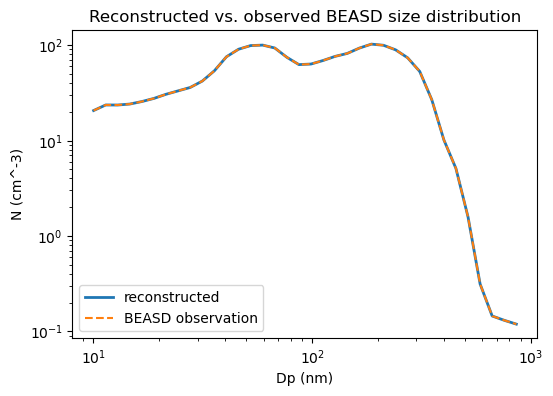

In [3]:
obs_lo, obs_hi, obs_N_cm3, _ = hiscale._read_beasd_avg_size_dist(
    beasd_file=config['beasd_file'],
    aimms_file=config['aimms_file'],
    z=config['z'],
    dz=config['dz'],
    beasd_density_measure='per_bin',
)
obs_mid = obs_lo + 0.5 * (obs_hi - obs_lo)
pop_sd = pop.metadata['size_distribution']
pop_mid = pop_sd['Dp_lo_nm'] + 0.5 * (pop_sd['Dp_hi_nm'] - pop_sd['Dp_lo_nm'])
pop_N_cm3 = pop_sd['N_bin_m3'] * 1e-6
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(pop_mid, pop_N_cm3, label='reconstructed', linewidth=2)
ax.plot(obs_mid, obs_N_cm3, label='BEASD observation', linestyle='--')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Dp (nm)')
ax.set_ylabel('N (cm^-3)')
ax.set_title('Reconstructed vs. observed BEASD size distribution')
ax.legend()


## miniSPLAT reduced-class comparison
Compare the builder-assigned reduced-class fractions to the averages from the original miniSPLAT table.

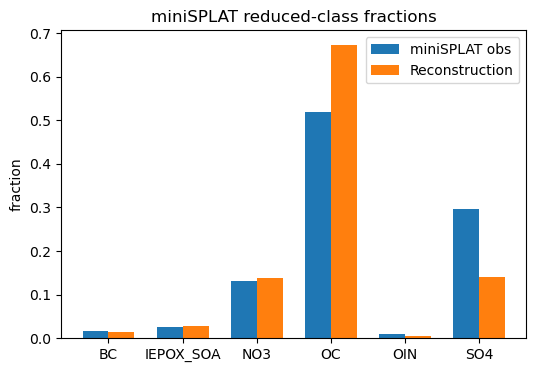

In [4]:
splat_table = hiscale._read_delimited_table_with_header(config['splat_file'])
obs_reduced = {}
for reduced, cols in config['splat_species'].items():
    values = np.zeros_like(next(iter(splat_table.values())))
    for col in cols:
        values += np.asarray(splat_table[col], dtype=float)
    obs_reduced[reduced] = float(np.nanmean(values))
norm = sum(obs_reduced.values())
obs_reduced = {k: v / norm for k, v in obs_reduced.items()}
model_reduced = pop.metadata['type_fracs']
labels = sorted(obs_reduced.keys())
obs_vals = [obs_reduced[label] for label in labels]
model_vals = [model_reduced.get(label, 0.0) for label in labels]
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width / 2, obs_vals, width, label='miniSPLAT obs')
ax.bar(x + width / 2, model_vals, width, label='Reconstruction')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('fraction')
ax.set_title('miniSPLAT reduced-class fractions')
ax.legend()


## frac_ccn state line
Create a `state_line` plotter for the `frac_ccn` variable, using the computed population to visualize how the derived fraction varies across the `s_grid`.

/Users/fier887/Library/CloudStorage/OneDrive-PNNL/Code/part2pop/src/part2pop/analysis/population/factory/frac_ccn.py:37: UserWarning: Both 's_grid' and 's_eval' provided with different lengths (50 vs 100). Using 's_grid'.
  warnings.warn(
/Users/fier887/Library/CloudStorage/OneDrive-PNNL/Code/part2pop/src/part2pop/aerosol_particle.py:269: UserWarning: Surface tension not implemented; returning default 0.072 N/m
  warnings.warn("Surface tension not implemented; returning default 0.072 N/m", UserWarning)


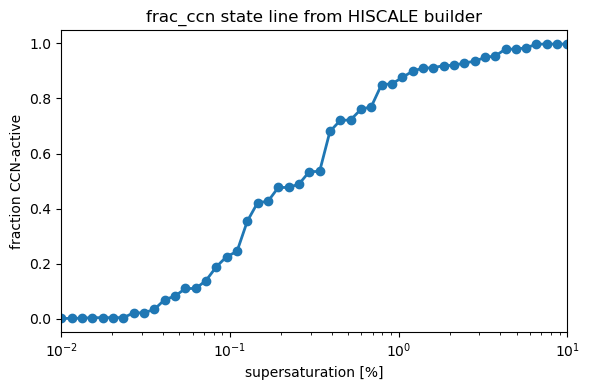

In [5]:
state_line_cfg = {
    'type': 'state_line',
    'varname': 'frac_ccn',
    'var_cfg': {'s_grid': np.logspace(-2, 1, 50)},
    'style': {'marker': 'o', 'linewidth': 2},
}
plotter = build_state_line(state_line_cfg)
fig, ax = plt.subplots(figsize=(6, 4))
plotter.plot(pop, ax, add_xlabel=True, add_ylabel=True)
ax.set_title('frac_ccn state line from HISCALE builder')
fig.tight_layout()


## Additional diagnostics
Compute summary metrics (total N, total mass, matching diagnostics) and compare the builder metadata to the observed FIMS/BEASD totals so readers can reconcile why CCN fractions behave the way they do.

In [6]:
total_obs = np.sum(obs_N_cm3)
total_recon = np.sum(pop_N_cm3)
print(f'BEASD total N (cm^-3): {total_obs:.3f}')
print(f'Reconstructed total N (cm^-3): {total_recon:.3f}')
if 'ams_mass_frac' in pop.metadata:
    print('AMS mass fractions (metadata):', pop.metadata['ams_mass_frac'])
ratio = total_recon / total_obs if total_obs > 0 else np.nan
print(f'Reconstructed/observed total N ratio: {ratio:.2f}')


BEASD total N (cm^-3): 1781.350
Reconstructed total N (cm^-3): 1781.350
AMS mass fractions (metadata): {'OC': 0.4781255445036973, 'NO3': 0.030483428982560276, 'SO4': 0.3583077671403279, 'NH4': 0.13308325937341445}
Reconstructed/observed total N ratio: 1.00
